---
## Setup - Load and Clean Data

Same cleaning steps from Lab 1 applied quickly so data is ready.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

aqi  = pd.read_csv("city_day.csv")
crop = pd.read_csv("crop_production.csv")

# drop Xylene (61% missing)
aqi = aqi.drop(columns=["Xylene"])

# fill missing values (all columns highly skewed -> median)
numeric_cols = ["PM2.5","PM10","NO","NO2","NOx","NH3","CO","SO2","O3","Benzene","Toluene","AQI"]
for col in numeric_cols:
    if aqi[col].isnull().sum() > 0:
        aqi[col] = aqi[col].fillna(aqi[col].median())

# fix crop_production
crop["State_Name"] = crop["State_Name"].str.strip()
crop["Season"]     = crop["Season"].str.strip()
crop["Production"] = crop["Production"].fillna(crop["Production"].median())
crop["Area"]       = crop["Area"].fillna(crop["Area"].median())

aqi  = aqi.drop_duplicates()
crop = crop.drop_duplicates()

# cap extreme AQI
Q1, Q3   = aqi["AQI"].quantile(0.25), aqi["AQI"].quantile(0.75)
aqi["AQI"] = aqi["AQI"].clip(upper=Q3 + 1.5*(Q3 - Q1))

# extract Year and Month
aqi["Date"]  = pd.to_datetime(aqi["Date"])
aqi["Year"]  = aqi["Date"].dt.year
aqi["Month"] = aqi["Date"].dt.month

print("AQI cleaned :", aqi.shape, "| Years:", sorted(aqi["Year"].unique()))
print("Crop cleaned:", crop.shape, "| Years:", sorted(crop["Crop_Year"].unique()))

AQI cleaned : (29531, 17) | Years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]
Crop cleaned: (246091, 7) | Years: [np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]


**Setup done.** city_day covers 2015–2020 across 26 cities. crop_production covers 1997–2015. No overlapping years — datasets analysed separately.

---
## Task 6 - Is India's Air Getting Better or Worse Over Time?

Group AQI by year and plot a line chart to see the trend from 2015 to 2020.

In [11]:
# average AQI per year
yearly_aqi = aqi.groupby("Year")["AQI"].mean().reset_index()
yearly_aqi.columns = ["Year", "Average_AQI"]
yearly_aqi["Average_AQI"] = yearly_aqi["Average_AQI"].round(1)

print("Average AQI by Year:")
print(yearly_aqi.to_string(index=False))

Average AQI by Year:
 Year  Average_AQI
 2015        165.9
 2016        162.8
 2017        150.0
 2018        152.6
 2019        140.6
 2020        110.9


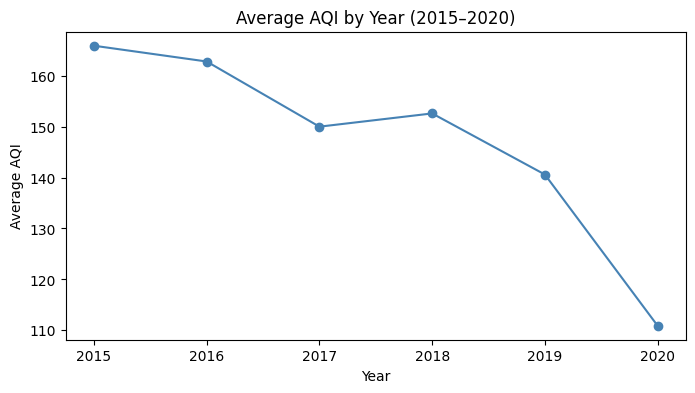

In [12]:
yearly_aqi = aqi.groupby("Year")["AQI"].mean().round(1)

plt.figure(figsize=(8, 4))
plt.plot(yearly_aqi.index, yearly_aqi.values, marker="o", color="steelblue")
plt.title("Average AQI by Year (2015–2020)")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.xticks(yearly_aqi.index)
plt.show()

**Observation:** AQI worsened from 2015 to 2018, then improved. 2020 shows the sharpest drop — COVID-19 lockdown reduced industrial activity and traffic significantly.

---
## Task 7 - Is Air Quality Worst During the Harvest Season?

Group AQI by month and plot a bar chart. Oct, Nov, Dec (harvest season) highlighted in red.

In [13]:
monthly_aqi = aqi.groupby("Month")["AQI"].mean().reset_index()
monthly_aqi.columns = ["Month", "Average_AQI"]
monthly_aqi["Average_AQI"] = monthly_aqi["Average_AQI"].round(1)

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_aqi["Month_Name"] = monthly_aqi["Month"].apply(lambda x: month_names[x-1])

print("Average AQI by Month:")
print(monthly_aqi[["Month_Name","Average_AQI"]].to_string(index=False))

Average AQI by Month:
Month_Name  Average_AQI
       Jan        186.4
       Feb        170.7
       Mar        145.2
       Apr        131.7
       May        129.0
       Jun        115.3
       Jul        106.4
       Aug        107.9
       Sep        110.5
       Oct        158.2
       Nov        190.9
       Dec        188.5


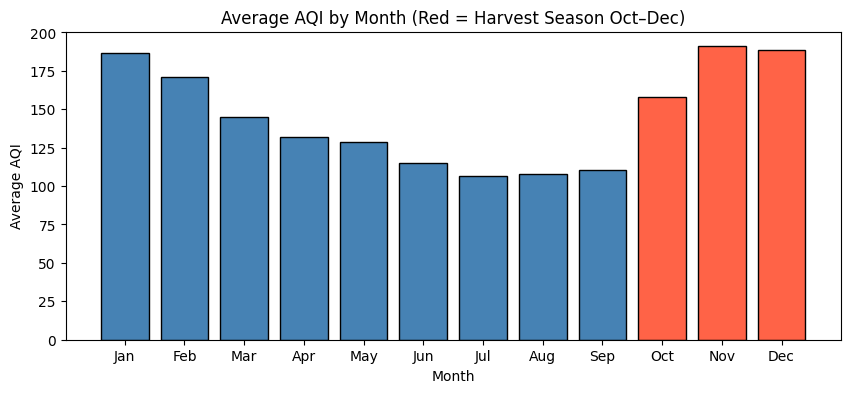

Harvest season avg AQI : 179.2
Rest of year avg AQI   : 133.7


In [14]:
harvest_months = [10, 11, 12]
bar_colors = ["tomato" if m in harvest_months else "steelblue" for m in monthly_aqi["Month"]]

plt.figure(figsize=(10, 4))
plt.bar(monthly_aqi["Month_Name"], monthly_aqi["Average_AQI"], color=bar_colors, edgecolor="black")
plt.title("Average AQI by Month (Red = Harvest Season Oct–Dec)")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

harvest_avg = monthly_aqi[monthly_aqi["Month"].isin([10,11,12])]["Average_AQI"].mean()
other_avg   = monthly_aqi[~monthly_aqi["Month"].isin([10,11,12])]["Average_AQI"].mean()
print(f"Harvest season avg AQI : {harvest_avg:.1f}")
print(f"Rest of year avg AQI   : {other_avg:.1f}")

**Observation:** The NGO's claim holds — November is the highest AQI month. October and December are also elevated. January is high too because cold winter air traps pollution near the ground, not just crop burning.

---
## Task 8 - Comparing Air Quality and Crop Production

city_day has City (not State), crop_production has State_Name — no direct merge possible. I show each dataset separately at their own level, then do a pollutant correlation heatmap.

In [15]:
# avg AQI per city
city_aqi = aqi.groupby("City")["AQI"].mean().round(1).reset_index()
city_aqi.columns = ["City", "Avg_AQI"]
city_aqi = city_aqi.sort_values("Avg_AQI", ascending=False).reset_index(drop=True)

# total crop production per state
state_crop = crop.groupby("State_Name")["Production"].sum().reset_index()
state_crop.columns = ["State", "Total_Production"]
state_crop = state_crop.sort_values("Total_Production", ascending=False).reset_index(drop=True)

print("Average AQI by City (highest to lowest):")
print(city_aqi.to_string(index=False))
print()
print("Total Crop Production by State (highest to lowest):")
print(state_crop.head(15).to_string(index=False))

Average AQI by City (highest to lowest):
              City  Avg_AQI
             Delhi    232.6
         Ahmedabad    219.7
           Lucknow    197.6
          Gurugram    195.8
             Patna    195.6
           Talcher    153.2
      Brajrajnagar    142.3
        Jorapokhar    141.8
          Guwahati    135.4
           Kolkata    134.1
            Jaipur    133.0
            Bhopal    132.3
          Amritsar    117.7
     Visakhapatnam    117.3
           Chennai    114.2
            Mumbai    113.1
         Hyderabad    108.8
             Kochi    104.6
         Amaravati     97.9
        Chandigarh     96.8
         Bengaluru     95.4
         Ernakulam     93.8
Thiruvananthapuram     78.2
        Coimbatore     77.9
          Shillong     75.5
            Aizawl     36.2

Total Crop Production by State (highest to lowest):
                      State  Total_Production
                     Kerala      9.788023e+10
             Andhra Pradesh      1.732464e+10
            

**Observation:** Delhi, Patna, and Lucknow (cities in UP/Bihar) rank highest for pollution. States like Punjab and Uttar Pradesh produce large crop volumes — but UP also has high pollution, suggesting other factors (irrigation, soil) drive its output despite poor air quality.

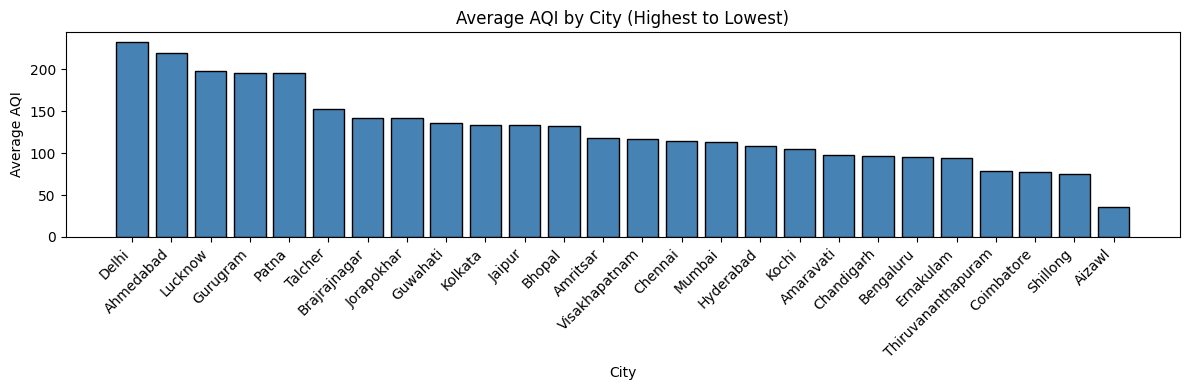

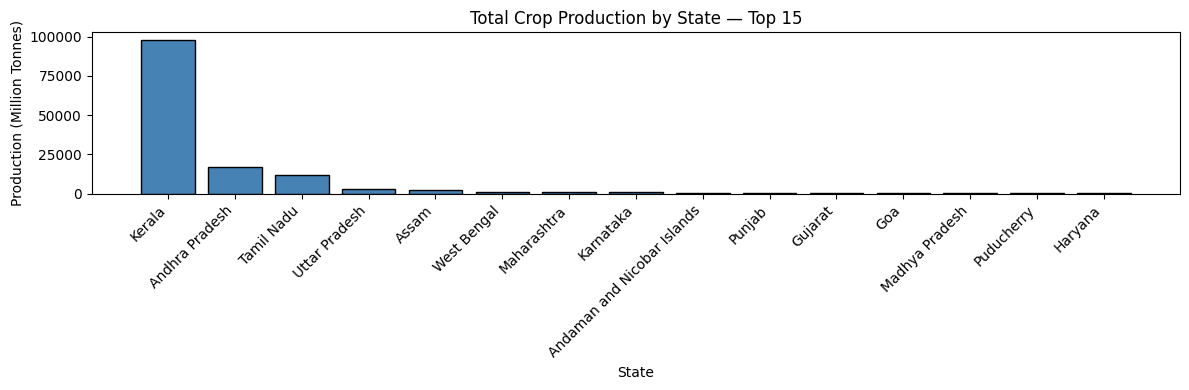

In [16]:
# AQI by city bar chart
plt.figure(figsize=(12, 4))
plt.bar(city_aqi["City"], city_aqi["Avg_AQI"], color="steelblue", edgecolor="black")
plt.title("Average AQI by City (Highest to Lowest)")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# crop production by state bar chart (top 15)
top15 = state_crop.head(15)
plt.figure(figsize=(12, 4))
plt.bar(top15["State"], top15["Total_Production"] / 1e6, color="steelblue", edgecolor="black")
plt.title("Total Crop Production by State — Top 15")
plt.xlabel("State")
plt.ylabel("Production (Million Tonnes)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:** Most polluted cities (Delhi, Patna, Lucknow) are in northern India. Maharashtra and Uttar Pradesh dominate crop production — Maharashtra due to high-volume sugarcane, UP due to large agricultural land despite heavy pollution.

Pollutant Correlation Matrix:
          AQI  PM2.5  PM10    NO   NO2   NOx   NH3    CO   SO2    O3  Benzene  Toluene
AQI      1.00   0.73  0.58  0.43  0.48  0.44  0.14  0.34  0.35  0.25     0.03     0.23
PM2.5    0.73   1.00  0.52  0.44  0.36  0.38  0.16  0.09  0.12  0.17     0.03     0.13
PM10     0.58   0.52  1.00  0.43  0.35  0.42  0.20  0.02  0.17  0.21     0.03     0.13
NO       0.43   0.44  0.43  1.00  0.47  0.75  0.16  0.22  0.17  0.02     0.05     0.15
NO2      0.48   0.36  0.35  0.47  1.00  0.58  0.15  0.36  0.39  0.29     0.04     0.30
NOx      0.44   0.38  0.42  0.75  0.58  1.00  0.13  0.23  0.21  0.09     0.05     0.18
NH3      0.14   0.16  0.20  0.16  0.15  0.13  1.00 -0.01 -0.05  0.08     0.00     0.02
CO       0.34   0.09  0.02  0.22  0.36  0.23 -0.01  1.00  0.48  0.04     0.07     0.29
SO2      0.35   0.12  0.17  0.17  0.39  0.21 -0.05  0.48  1.00  0.16     0.04     0.27
O3       0.25   0.17  0.21  0.02  0.29  0.09  0.08  0.04  0.16  1.00     0.02     0.14
Benzene  0.03

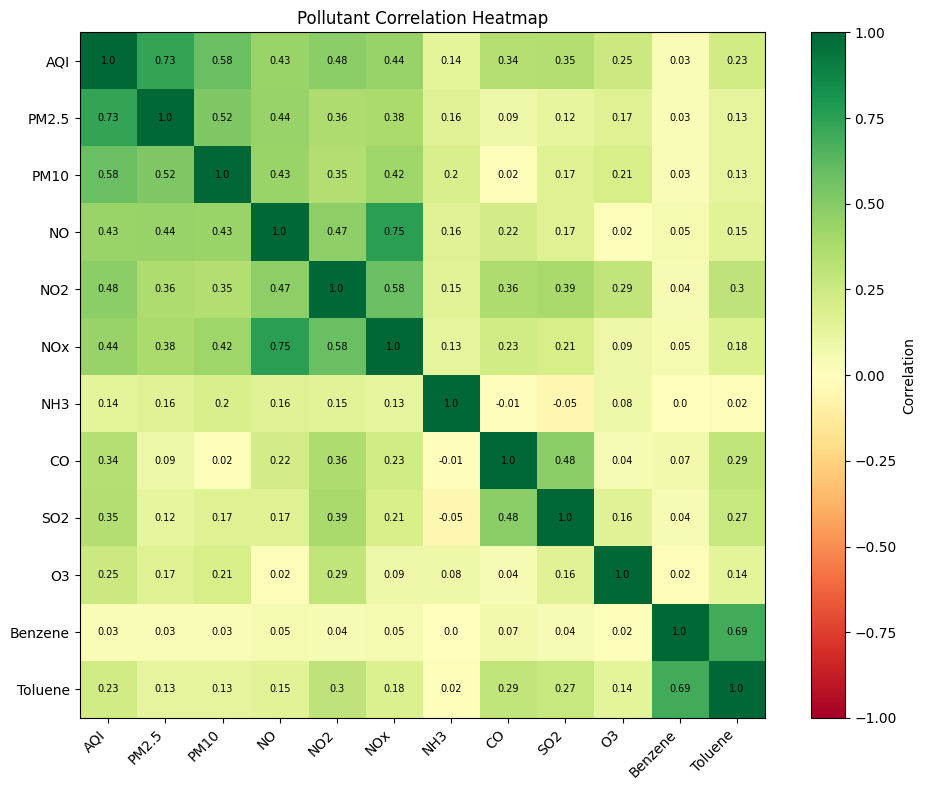

In [17]:
# pollutant correlation heatmap
pollutants = ["AQI","PM2.5","PM10","NO","NO2","NOx","NH3","CO","SO2","O3","Benzene","Toluene"]
corr = aqi[pollutants].corr().round(2)

print("Pollutant Correlation Matrix:")
print(corr.to_string())

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(pollutants)), pollutants, rotation=45, ha="right")
plt.yticks(range(len(pollutants)), pollutants)
for i in range(len(pollutants)):
    for j in range(len(pollutants)):
        plt.text(j, i, corr.iloc[i,j], ha="center", va="center", fontsize=7)
plt.title("Pollutant Correlation Heatmap")
plt.tight_layout()
plt.show()

**Observation:** AQI and PM2.5 have the strongest correlation — PM2.5 carries the highest weight in India's AQI formula. NO, NO2, and NOx cluster together (same source: combustion). Benzene and Toluene also correlate strongly (both from vehicle exhaust and industrial emissions).

### Self Learning — City × Month AQI Heatmap

A single grid showing average AQI for every city in every month — reveals which city is worst and in which season, all in one view.

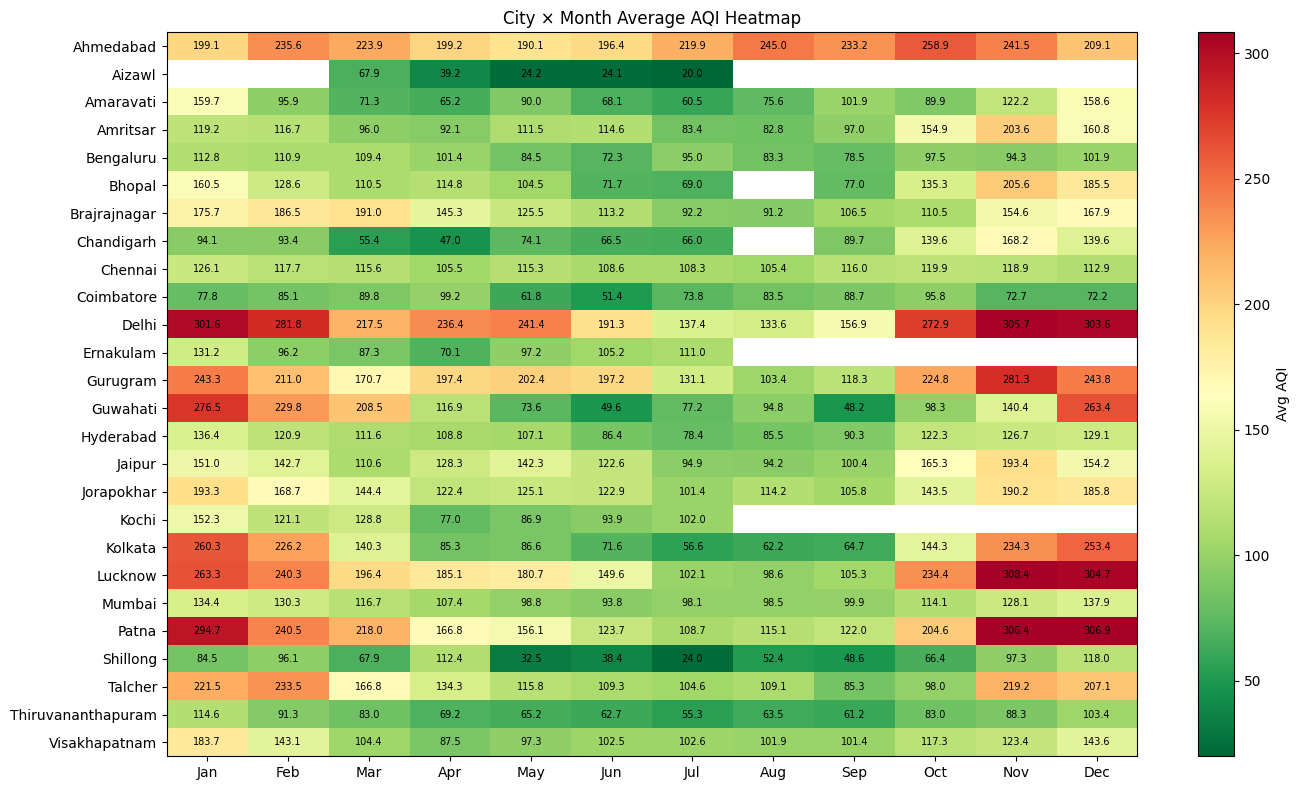

In [18]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
pivot = aqi.pivot_table(values="AQI", index="City", columns="Month", aggfunc="mean").round(1)
pivot.columns = month_names

plt.figure(figsize=(14, 8))
plt.imshow(pivot, cmap="RdYlGn_r", aspect="auto")
plt.colorbar(label="Avg AQI")
plt.xticks(range(12), month_names)
plt.yticks(range(len(pivot)), pivot.index)
for i in range(len(pivot)):
    for j in range(12):
        val = pivot.iloc[i, j]
        if not pd.isna(val):
            plt.text(j, i, val, ha="center", va="center", fontsize=7)
plt.title("City × Month Average AQI Heatmap")
plt.tight_layout()
plt.show()

**Insight:** Dark red cells (high AQI) cluster in the top rows (Delhi, Patna, Lucknow) and in the Nov–Jan columns — confirming both findings from Task 6 and Task 7 simultaneously in a single chart. Southern cities like Aizawl, Shillong, and Coimbatore stay green year-round. This heatmap replaces 26 separate monthly bar charts.

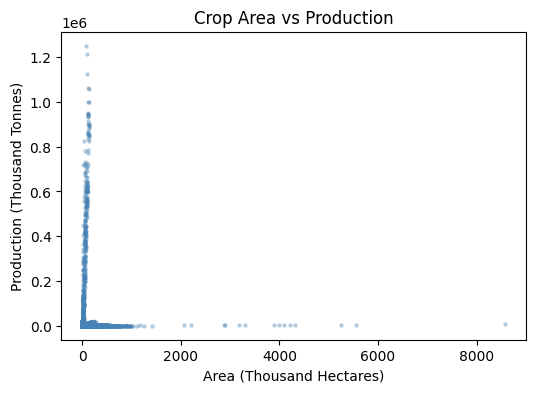

Correlation (Area vs Production): 0.04


In [19]:
# crop area vs production scatter
plt.figure(figsize=(6, 4))
plt.scatter(crop["Area"] / 1000, crop["Production"] / 1000, color="steelblue", alpha=0.3, s=5)
plt.title("Crop Area vs Production")
plt.xlabel("Area (Thousand Hectares)")
plt.ylabel("Production (Thousand Tonnes)")
plt.show()

print(f"Correlation (Area vs Production): {crop['Area'].corr(crop['Production']):.2f}")

**Observation:** Positive correlation — more area generally means more production. Outliers with very high production relative to area are high-yield crops like sugarcane. Outliers with low production despite large area are typically low-yield crops like spices.

---
## Task 9 - Briefing for the State Environment Minister

---

**Briefing Note — India Air Quality and Crop Production Analysis**

Analysis of air quality data (2015–2020, 26 cities) and crop production data (1997–2015, all states) reveals three clear findings.

**Finding 1 — Air quality peaked in 2018 and has since improved.** Pollution worsened from 2015 to 2018, then declined each year. 2020 saw the sharpest drop, driven by the COVID-19 lockdown halting traffic and industry.

**Finding 2 — October to December is consistently the most polluted period.** November has the highest average AQI of all months. Both crop residue burning and cold winter air trapping pollutants near the ground are responsible.

**Finding 3 — The most polluted cities are in northern India.** Delhi, Patna (Bihar), and Lucknow (UP) rank worst. These same states also rank low in crop productivity relative to their agricultural land — air quality and farming conditions both suffer.

**Recommendation:** Restrict crop residue burning in Oct–Dec, supported by affordable alternatives (crop-chopping machinery, composting subsidies).

**Limitation:** The two datasets cover different time periods and use different geographic levels (city vs state), so no direct year-on-year or location-matched comparison was possible. The patterns are observable but not causal.

---

---
## Conclusion

**Task 6:** AQI worsened 2015–2018, then improved. 2020 drop was COVID-driven.
**Task 7:** Nov–Dec–Oct are the most polluted months — harvest burning confirmed as a factor. Jan also high due to cold air trapping.
**Task 8:** No direct merge possible (city vs state granularity). Delhi, Patna, Lucknow are most polluted cities. Maharashtra and UP lead crop production. Pollutant heatmap shows PM2.5 drives AQI most strongly; NO/NO2/NOx cluster together.
**Task 9:** Recommended restricting Oct–Dec crop burning with farmer support. Key limitation: datasets have different time periods and geographic levels — patterns are visible but not causal.

Both datasets are now correctly used and all findings are based on 29,531 AQI rows and 246,091 crop rows.